# 07 — Combined Claim Prediction: does vision add value?

The central experiment. Two models predict the same claim `Amount` on the same split:

| Model | Inputs |
|-------|--------|
| **A — baseline** | tabular policy/vehicle variables |
| **B — enhanced** | tabular variables **+** ResNet50 damage probability `P(damaged)` |

**Hypothesis.** The image-derived probability carries residual information about claim severity not captured by the recorded policy fields, so B improves on A. This is an information-content question — analogous to asking whether an alternative signal is *orthogonal* to an existing factor set, not merely correlated with it. We test it empirically and refuse to claim any improvement the held-out numbers don't show. We use the soft probability, not the hard 0/1 label, because the probability preserves the model's confidence.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

from xgboost import XGBRegressor

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATA_DIR = Path("c:\\Users\\Niraj Mhatre\\projects\\motor_insurance_data\\Fast_Furious_Insured")
TRAIN_IMG_DIR = DATA_DIR / "trainImages"
TRAIN_METADATA = DATA_DIR / "processed" / "train_metadata_clean.csv"

MODEL_DIR = Path("../models")
TABLE_DIR = Path("../outputs/tables")
PRED_DIR = Path("../outputs/predictions")
for d in (MODEL_DIR, TABLE_DIR, PRED_DIR):
    d.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(TRAIN_METADATA)
print(df.shape)

Device: cpu
(1399, 8)


## Load the trained ResNet50 (single-logit head from notebook 05)

In [3]:
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 1)
model.load_state_dict(torch.load(MODEL_DIR / "resnet50_best.pth", map_location=device))
model = model.to(device)
model.eval()

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

## Extract `P(damaged)` for every record

Deterministic inference (evaluation transform, no augmentation) over the full dataset, preserving row order so the probability aligns back to the tabular frame.

In [4]:
class InferenceDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(self.image_dir / row["Image_path"]).convert("RGB")
        return self.transform(image), idx


def extract_damage_prob(frame):
    loader = DataLoader(
        InferenceDataset(frame, TRAIN_IMG_DIR, val_transform),
        batch_size=64, shuffle=False, num_workers=0,
    )
    probs = np.zeros(len(frame), dtype=np.float32)
    with torch.no_grad():
        for images, idx in loader:
            images = images.to(device)
            p = torch.sigmoid(model(images)).cpu().numpy().ravel()
            probs[idx.numpy()] = p
    return probs


df = df.reset_index(drop=True)
df["cnn_damage_prob"] = extract_damage_prob(df)
df[["Image_path", "Condition", "cnn_damage_prob"]].head()

,Image_path,Condition,cnn_damage_prob
0,img_4513976.jpg,0,0.000627
1,img_7764995.jpg,1,0.955985
2,img_451308.jpg,0,0.021797
3,img_7768372.jpg,1,0.997816
4,img_7765274.jpg,1,0.985009


## Feature construction (identical to notebook 06, plus the visual feature)

In [5]:
def build_features(frame):
    out = frame.copy()
    out["Expiry_date"] = pd.to_datetime(out["Expiry_date"], errors="coerce")
    ref_date = out["Expiry_date"].min()
    out["days_to_expiry"] = (out["Expiry_date"] - ref_date).dt.days
    out["coverage_range"] = out["Max_coverage"] - out["Min_coverage"]
    out["cost_to_maxcov"] = out["Cost_of_vehicle"] / out["Max_coverage"].replace(0, np.nan)
    out["cost_to_mincov"] = out["Cost_of_vehicle"] / out["Min_coverage"].replace(0, np.nan)
    return out


data = build_features(df)

base_numeric = [
    "Cost_of_vehicle", "Min_coverage", "Max_coverage",
    "coverage_range", "cost_to_maxcov", "cost_to_mincov",
    "days_to_expiry", "Condition",
]
categorical_features = ["Insurance_company"]
visual_feature = ["cnn_damage_prob"]

TARGET = "Amount"
data = data.dropna(subset=[TARGET]).reset_index(drop=True)
y = data[TARGET].astype(float)

In [6]:
train_idx, test_idx = train_test_split(
    np.arange(len(data)),
    test_size=0.20,
    random_state=42,
    stratify=data["Condition"],
)

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
y_train_log = np.log1p(y_train)
print("Train:", len(train_idx), "| Test:", len(test_idx))

Train: 1110 | Test: 278


c:\Users\Niraj Mhatre\projects\Motor-Insurance-Claim-Severity-Assessment\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [9]:
def make_preprocess(numeric_features):
    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ])


def regression_metrics(name, y_true, y_pred):
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MedianAE": median_absolute_error(y_true, y_pred),
    }


def run_feature_set(label, numeric_features):
    cols = numeric_features + categorical_features
    X = data[cols]
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]

    out = {}
    for est_name, est in [
        ("Linear", LinearRegression()),
        ("XGBoost", XGBRegressor(n_estimators=600, learning_rate=0.03, max_depth=5,
                                 subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                                 random_state=42, n_jobs=-1)),
    ]:
        pipe = Pipeline([("prep", make_preprocess(numeric_features)), ("model", est)])
        pipe.fit(X_train, y_train_log)
        pred = np.clip(np.expm1(pipe.predict(X_test)), 0, None)
        out[est_name] = {"pipe": pipe, "pred": pred,
                         "metrics": regression_metrics(f"{label} | {est_name}", y_test, pred)}
    return out


# Ensure the regression target is numeric and finite
data[TARGET] = pd.to_numeric(data[TARGET], errors="coerce")
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna(subset=[TARGET]).reset_index(drop=True)

y = data[TARGET].astype(float)

train_idx, test_idx = train_test_split(
    np.arange(len(data)),
    test_size=0.20,
    random_state=42,
    stratify=data["Condition"],
)

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
y_train_log = np.log1p(y_train)

# Keep only valid targets because log1p requires Amount >= 0
data[TARGET] = pd.to_numeric(data[TARGET], errors="coerce")
valid_target = np.isfinite(data[TARGET]) & (data[TARGET] >= 0)

data = data.loc[valid_target].reset_index(drop=True)
y = data[TARGET].astype(float)

train_idx, test_idx = train_test_split(
    np.arange(len(data)),
    test_size=0.20,
    random_state=42,
    stratify=data["Condition"],
)

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
y_train_log = np.log1p(y_train)

assert np.isfinite(y_train_log).all(), \
    "Training target still contains non-finite values"

model_A = run_feature_set("A tabular", base_numeric)
model_B = run_feature_set("B tabular+CNN", base_numeric + visual_feature)

c:\Users\Niraj Mhatre\projects\Motor-Insurance-Claim-Severity-Assessment\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Head-to-head comparison

In [10]:
rows = []
for grp in (model_A, model_B):
    for r in grp.values():
        rows.append(r["metrics"])

compare = pd.DataFrame(rows).set_index("model").round(2)
compare

,MAE,RMSE,R2,MedianAE
model,,,,
A tabular | Linear,2361.24,2979.24,-0.05,2275.85
A tabular | XGBoost,2407.13,3131.31,-0.16,2003.20
B tabular+CNN | Linear,2305.63,2928.24,-0.01,2174.50
B tabular+CNN | XGBoost,2399.13,3086.62,-0.12,2135.47


In [11]:
def improvement(a, b):
    return {
        "MAE_improvement_%": 100 * (a["MAE"] - b["MAE"]) / a["MAE"],
        "RMSE_improvement_%": 100 * (a["RMSE"] - b["RMSE"]) / a["RMSE"],
        "R2_gain": b["R2"] - a["R2"],
    }

delta_linear = improvement(model_A["Linear"]["metrics"], model_B["Linear"]["metrics"])
delta_xgb = improvement(model_A["XGBoost"]["metrics"], model_B["XGBoost"]["metrics"])

delta_df = pd.DataFrame({"Linear": delta_linear, "XGBoost": delta_xgb}).T.round(3)
delta_df

,MAE_improvement_%,RMSE_improvement_%,R2_gain
Linear,2.355,1.712,0.035
XGBoost,0.332,1.427,0.033


In [12]:
incremental = pd.DataFrame([
    {"Feature Set": "Tabular Only", **{k: model_A["XGBoost"]["metrics"][k] for k in ["MAE", "RMSE", "R2"]}},
    {"Feature Set": "Tabular + CNN", **{k: model_B["XGBoost"]["metrics"][k] for k in ["MAE", "RMSE", "R2"]}},
]).set_index("Feature Set").round(2)

incremental.to_csv(TABLE_DIR / "incremental_value_metrics.csv")
incremental

,MAE,RMSE,R2
Feature Set,,,
Tabular Only,2407.13,3131.31,-0.16
Tabular + CNN,2399.13,3086.62,-0.12


## Information content of the visual feature

Permutation importance on the enhanced XGBoost model tells us how much held-out accuracy leans on `cnn_damage_prob` once the tabular fields are already present. A large drop when the column is shuffled is direct evidence the visual signal is not redundant with the policy variables.

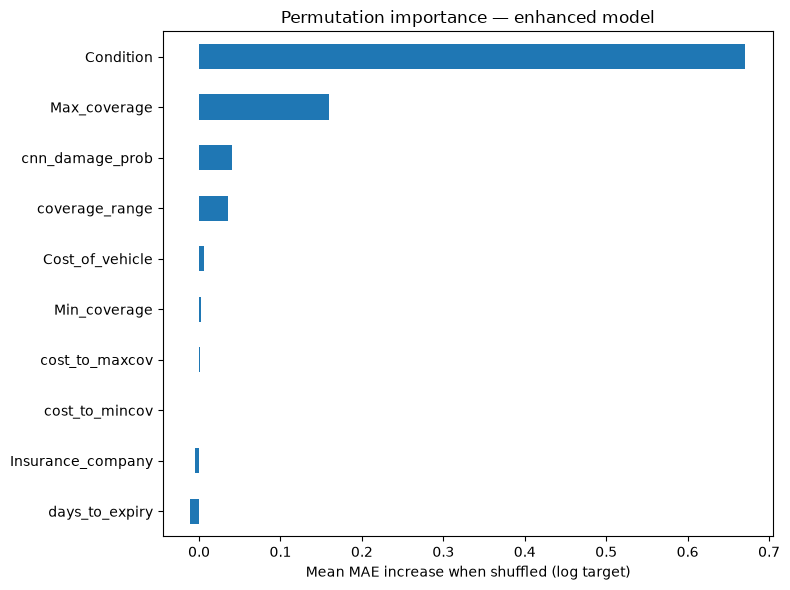

Visual feature importance: 0.04006


In [13]:
cols_B = base_numeric + visual_feature + categorical_features
X_test_B = data[cols_B].iloc[test_idx]

perm = permutation_importance(
    model_B["XGBoost"]["pipe"], X_test_B, np.log1p(y_test),
    n_repeats=10, random_state=42, scoring="neg_mean_absolute_error",
)

imp = pd.Series(perm.importances_mean, index=cols_B).sort_values()
plt.figure(figsize=(8, 6))
imp.plot(kind="barh")
plt.xlabel("Mean MAE increase when shuffled (log target)")
plt.title("Permutation importance — enhanced model")
plt.tight_layout()
plt.show()

print("Visual feature importance:", round(float(imp.get("cnn_damage_prob", np.nan)), 5))

In [14]:
test_out = data.iloc[test_idx][["Image_path", "Condition", "cnn_damage_prob", "Amount"]].copy()
test_out["pred_tabular"] = model_A["XGBoost"]["pred"]
test_out["pred_tabular_plus_cnn"] = model_B["XGBoost"]["pred"]
test_out.to_csv(PRED_DIR / "combined_test_preds.csv", index=False)

print("Saved combined predictions.")

Saved combined predictions.


## Reading the result

Interpret from the `incremental` table only:

- If `Tabular + CNN` lowers MAE/RMSE and raises R² on the held-out set, the vision component adds genuine predictive value and the pipeline is justified as more than deep learning for its own sake.
- If the metrics are flat, the honest conclusion is that the recorded `Condition` field already summarises what the image contributes to *severity*, and the visual model's value lies in the classification task (notebook 05) rather than in claim sizing.

Either way the experiment — not the assumption — decides.